In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns       
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import torch 
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import json
from io import StringIO



In [ ]:
#Load the datasets

price_path_0 = "CSV Data/prices_round_1_day_0.csv"
trades_path_0 = "CSV Data/trades_round_1_day_0.csv"
price_path_1 = "CSV Data\prices_round_1_day_-1.csv"
trades_path_1 = "CSV Data/trades_round_1_day_-1.csv"
price_path_2 = "CSV Data/prices_round_1_day_-2.csv"
trades_path_2 = "CSV Data/trades_round_1_day_-2.csv"


prices_data_01 = pd.read_csv(price_path_1, sep=";")
trades_data_01 = pd.read_csv(trades_path_1, sep=";")
prices_data_02 = pd.read_csv(price_path_2, sep=";")
trades_data_02 = pd.read_csv(trades_path_2, sep=";")
prices_data_0 = pd.read_csv(price_path_0, sep=";")
trades_data_0 = pd.read_csv(trades_path_0, sep=";")



print(prices_data_01.shape[0])
print(trades_data_01.shape[0])


20000
760


,timestamp,buyer,seller,symbol,currency,price,quantity


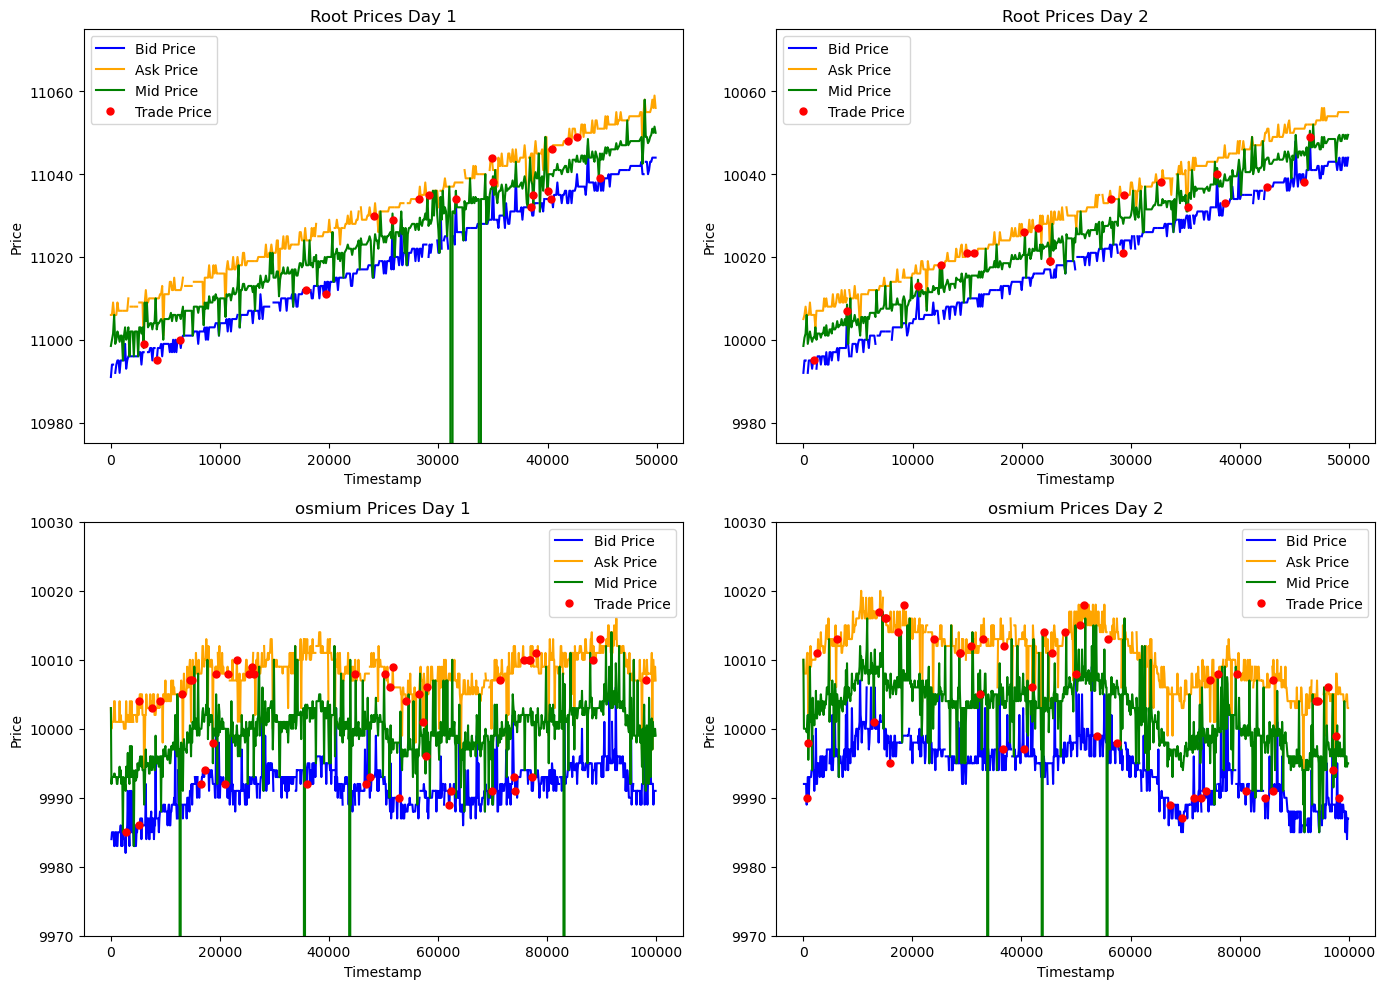

In [ ]:
# split tomato and emerald data
prices_data_01_root = prices_data_01[prices_data_01['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy()
prices_data_01_osmium = prices_data_01[prices_data_01['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()
prices_data_02_root = prices_data_02[prices_data_02['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy()
prices_data_02_osmium = prices_data_02[prices_data_02['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()
prices_data_0_root = prices_data_0[prices_data_0['product'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['product']).copy() 
prices_data_0_osmium = prices_data_0[prices_data_0['product'] == 'ASH_COATED_OSMIUM'].drop(columns=['product']).copy()  

trades_data_01_root = trades_data_01[trades_data_01['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_01_osmium = trades_data_01[trades_data_01['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()
trades_data_02_root = trades_data_02[trades_data_02['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_02_osmium = trades_data_02[trades_data_02['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()
trades_data_0_root = trades_data_0[trades_data_0['symbol'] == 'INTARIAN_PEPPER_ROOT'].drop(columns=['symbol']).copy()
trades_data_0_osmium = trades_data_0[trades_data_0['symbol'] == 'ASH_COATED_OSMIUM'].drop(columns=['symbol']).copy()


fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6)) = plt.subplots(3, 2, figsize=(14, 15))


root_pv = 500

#filter trades up to osmium_pv
trades_data_01_root = trades_data_01_root[trades_data_01_root["timestamp"] <= root_pv*100]
trades_data_02_root = trades_data_02_root[trades_data_02_root["timestamp"] <= root_pv*100]

#root day 0
ax5.plot(prices_data_0_root["timestamp"][:500], prices_data_0_root["bid_price_1"][:500], label="Bid Price", color="blue")
ax5.plot(prices_data_0_root["timestamp"][:500], prices_data_0_root["ask_price_1"][:500], label="Ask Price", color="orange")
ax5.plot(prices_data_0_root["timestamp"][:500], prices_data_0_root["mid_price"][:500  ], label="Mid Price", color="green")
ax5.plot(trades_data_0_root["timestamp"], trades_data_0_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax5.set_title("Root Prices Day 0")
ax5.set_ylim(10975, 11075)
ax5.set_xlabel("Timestamp")
ax5.set_ylabel("Price")
ax5.legend()


# root day 1

ax1.plot(prices_data_01_root["timestamp"][:500], prices_data_01_root["bid_price_1"][:500], label="Bid Price", color="blue")
ax1.plot(prices_data_01_root["timestamp"][:500], prices_data_01_root["ask_price_1"][:500], label="Ask Price", color="orange")
ax1.plot(prices_data_01_root["timestamp"][:500], prices_data_01_root["mid_price"][:500  ], label="Mid Price", color="green")
ax1.plot(trades_data_01_root["timestamp"], trades_data_01_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax1.set_title("Root Prices Day 1")
ax1.set_ylim(10975, 11075)
ax1.set_xlabel("Timestamp")
ax1.set_ylabel("Price")
ax1.legend()

# root day 2
ax2.plot(prices_data_02_root["timestamp"][:500], prices_data_02_root["bid_price_1"][:500], label="Bid Price", color="blue")
ax2.plot(prices_data_02_root["timestamp"][:500], prices_data_02_root["ask_price_1"][:500], label="Ask Price", color="orange")
ax2.plot(prices_data_02_root["timestamp"][:500], prices_data_02_root["mid_price"][:500  ], label="Mid Price", color="green")
ax2.plot(trades_data_02_root["timestamp"], trades_data_02_root["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax2.set_title("Root Prices Day 2")
ax2.set_xlabel("Timestamp")
ax2.set_ylim(9975, 10075)
ax2.set_ylabel("Price")
ax2.legend()



osmium_pv = 1000

#filter trades up to osmium_pv
trades_data_01_osmium = trades_data_01_osmium[trades_data_01_osmium["timestamp"] <= osmium_pv*100]
trades_data_02_osmium = trades_data_02_osmium[trades_data_02_osmium["timestamp"] <= osmium_pv*100]

#osmium day 0
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax6.plot(prices_data_0_osmium["timestamp"][:osmium_pv], prices_data_0_osmium["mid_price"][:osmium_pv], label="Mid Price ", color="green")
ax6.plot(trades_data_0_osmium["timestamp"], trades_data_0_osmium ["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)   
ax6.set_title("osmium Prices Day 0")
ax6.set_ylim(9970, 10030)
ax6.set_xlabel("Timestamp")
ax6.set_ylabel("Price")
ax6.legend()

ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax3.plot(prices_data_01_osmium["timestamp"][:osmium_pv], prices_data_01_osmium["mid_price"][:osmium_pv], label="Mid Price", color="green")
ax3.plot(trades_data_01_osmium["timestamp"], trades_data_01_osmium["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax3.set_title("osmium Prices Day 1")
ax3.set_ylim(9970, 10030)
ax3.set_xlabel("Timestamp")
ax3.set_ylabel("Price")
ax3.legend()

# osmium day 2
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["bid_price_1"][:osmium_pv], label="Bid Price", color="blue")
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["ask_price_1"][:osmium_pv], label="Ask Price", color="orange")
ax4.plot(prices_data_02_osmium["timestamp"][:osmium_pv], prices_data_02_osmium["mid_price"][:osmium_pv], label="Mid Price", color="green")
ax4.plot(trades_data_02_osmium["timestamp"], trades_data_02_osmium["price"], label="Trade Price", color="red", marker="o", linestyle="None", markersize=5)
ax4.set_title("osmium Prices Day 2")
ax4.set_xlabel("Timestamp")
ax4.set_ylim(9970, 10030)
ax4.set_ylabel("Price")
ax4.legend()




plt.tight_layout()
plt.show()


In [ ]:
#combine order book and trade data for root and osmium 




,timestamp,buyer,seller,currency,price,quantity
1,3400,NaN,NaN,XIRECS,5009.0,2
3,7000,NaN,NaN,XIRECS,5010.0,4
4,9600,NaN,NaN,XIRECS,4999.0,5
5,9900,NaN,NaN,XIRECS,5000.0,4
6,16400,NaN,NaN,XIRECS,4996.0,2
7,17900,NaN,NaN,XIRECS,5009.0,2
8,22200,NaN,NaN,XIRECS,5005.0,3
9,23500,NaN,NaN,XIRECS,4989.0,3
10,24600,NaN,NaN,XIRECS,5002.0,5
11,26100,NaN,NaN,XIRECS,4988.0,2
